## Plots similar to S12 for the other settings

In [3]:
import os
from pathlib import Path

from matplotlib import pyplot as plt
import seaborn as sns

from analysis.analysis_utils import load_results

def _plot_bow_facet(data, sorbent, targetname, hue='fingerprint'):
    x = 'model' if hue == 'fingerprint' else 'fingerprint'
    data_dict = {
        221: data[(data['crange'] == True) & (data['temperature'] == False) & (data['sorbent'] == sorbent)],
        222: data[(data['crange'] == True) & (data['temperature'] == True) & (data['sorbent'] == sorbent)],
        223: data[(data['crange'] == False) & (data['temperature'] == False) & (data['sorbent'] == sorbent)],
        224: data[(data['crange'] == False) & (data['temperature'] == True) & (data['sorbent'] == sorbent)],
    }
    # stripplot integration
    # copyright cc-by-sa johanC https://stackoverflow.com/a/67374479
    fig = plt.figure(layout='constrained', figsize=(8, 6))
    fig.subfigures(2, 1)
    needs_legend = True
    handles, labels = None, None
    for place, data in data_dict.items():
        sns.boxplot(
            data=data.dropna(axis='rows', how='any').explode(column='score').reset_index(),
            x=x, y='score', hue=hue, legend=needs_legend,
            boxprops={'alpha': 0.4}, ax=plt.subplot(place)
        )
        if needs_legend:
            handles, labels = plt.gca().get_legend_handles_labels()
            needs_legend = False
            plt.gca().get_legend().remove()
        sns.stripplot(
            data=data.dropna(axis='rows', how='any').explode(column='score').reset_index(),
            x=x, y='score', hue=hue, legend=needs_legend,
            dodge=True, s=2.5, ax=plt.subplot(place)
        )
        plt.subplot(place).tick_params(axis='both', labelsize='small')
    fig.supylabel("Use concentration range")
    plt.subplot(221).set_title("20°C & 25°C")
    plt.subplot(221).set_xlabel("")
    plt.subplot(221).set_ylabel("True", labelpad=10)
    plt.subplot(222).set_xlabel("")
    plt.subplot(222).set_ylabel(f"RMSE of " + str(targetname))
    plt.subplot(222).set_title("all")
    plt.subplot(223).set_ylabel("False", labelpad=10)
    plt.subplot(224).set_ylabel(f"RMSE of " + str(targetname))
    fig.suptitle("Temperature\n ")
    fig.legend(
        handles, labels, loc='outside lower center', bbox_to_anchor=(0.5, -0.05),
                ncols=5
    )

### Plots for the filter targets

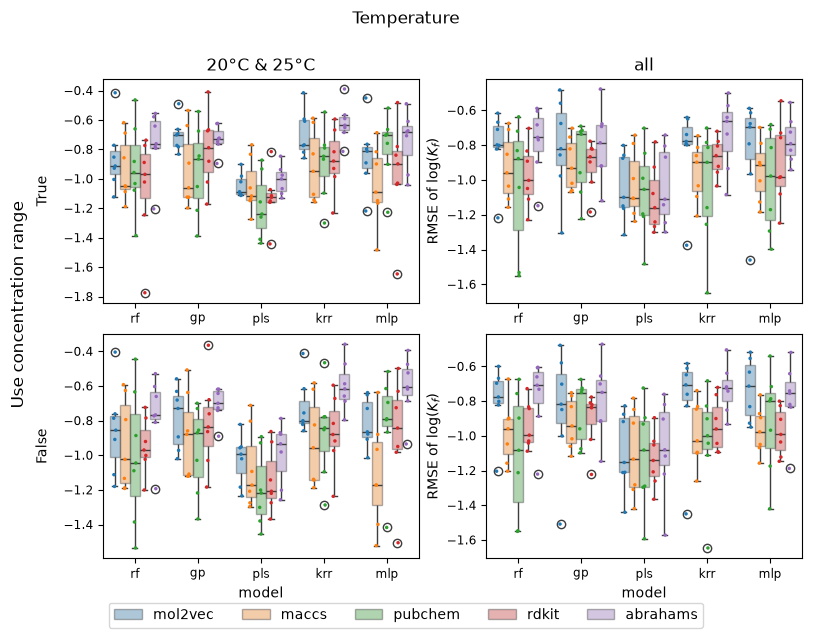

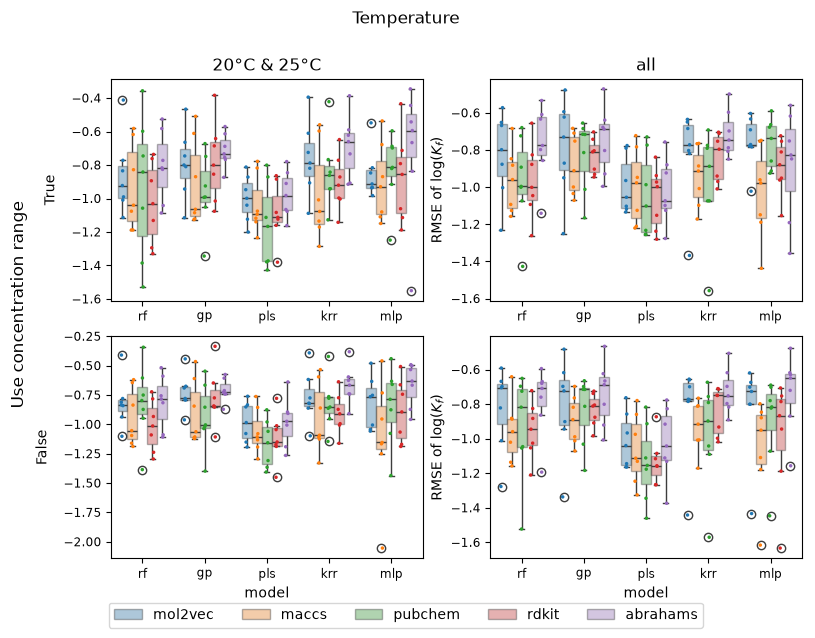

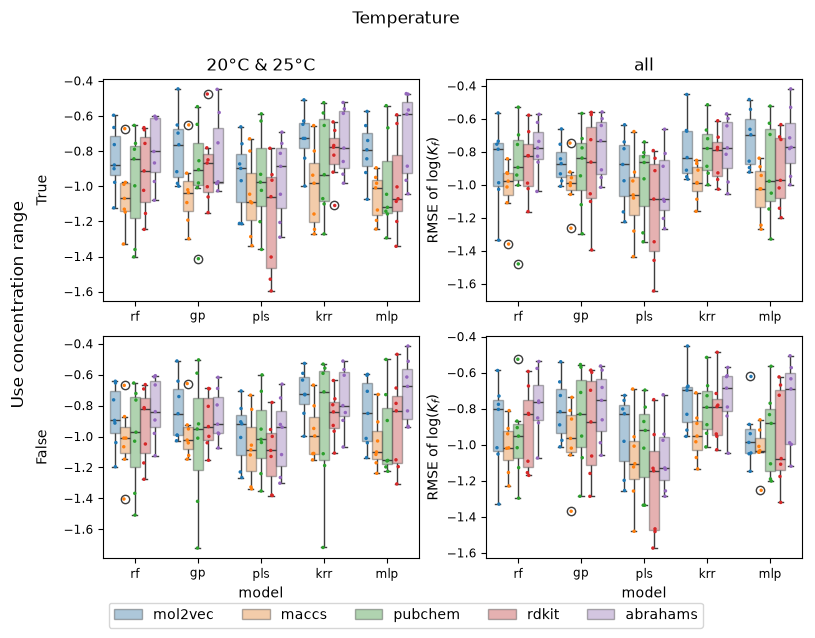

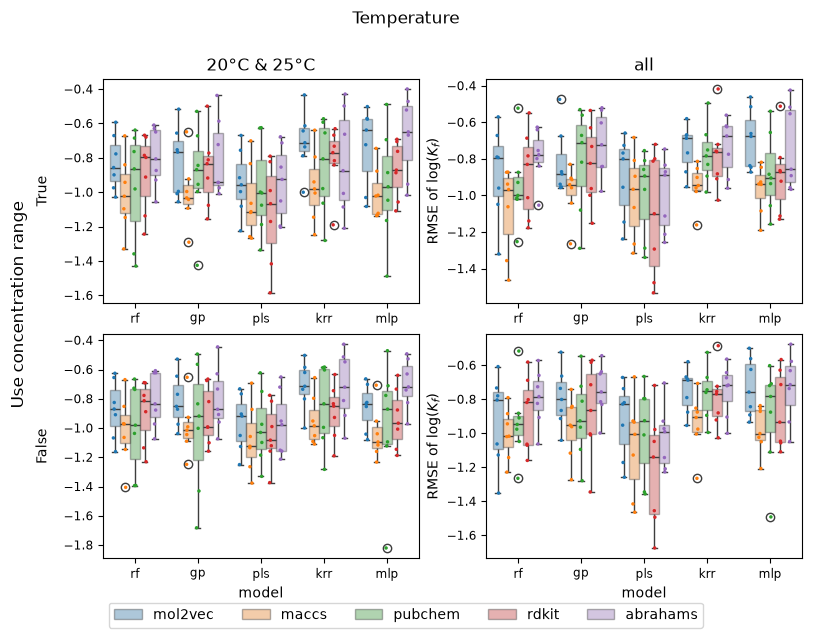

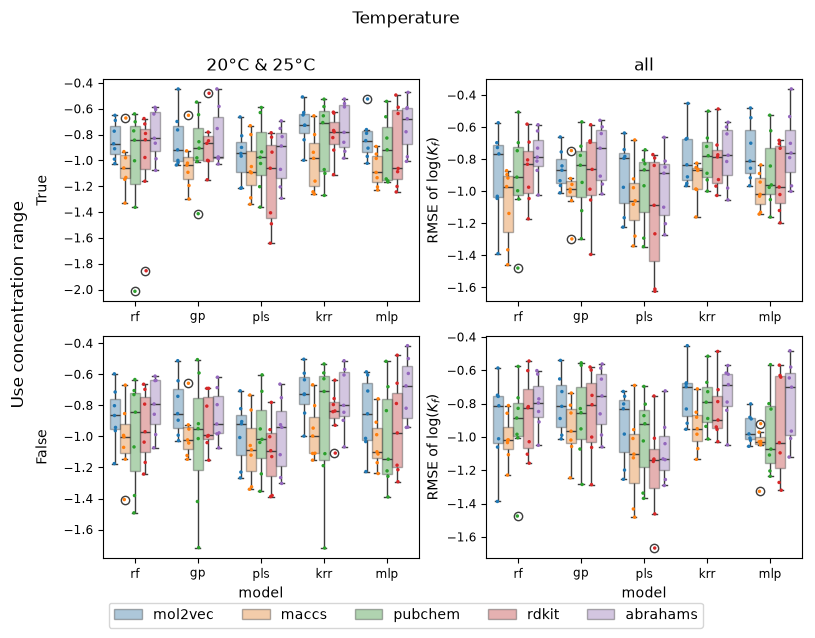

...

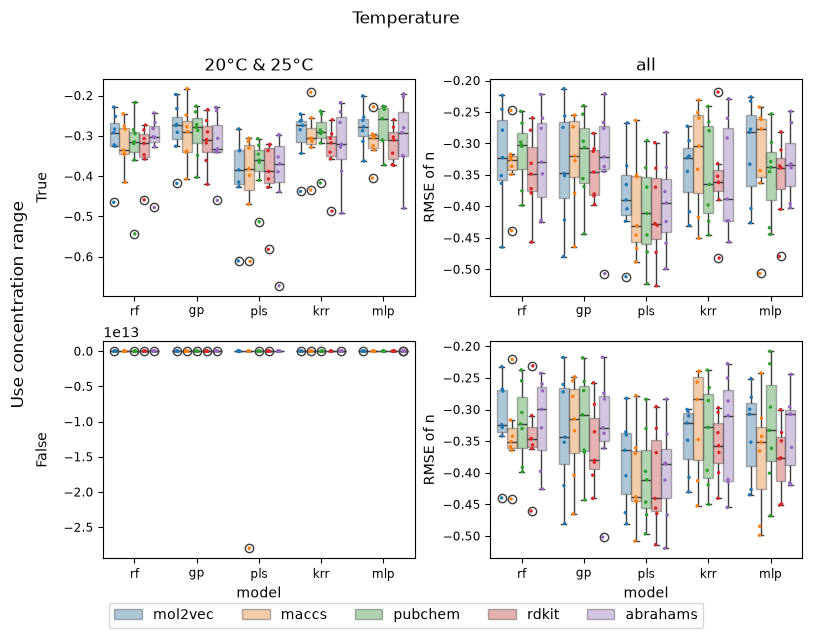

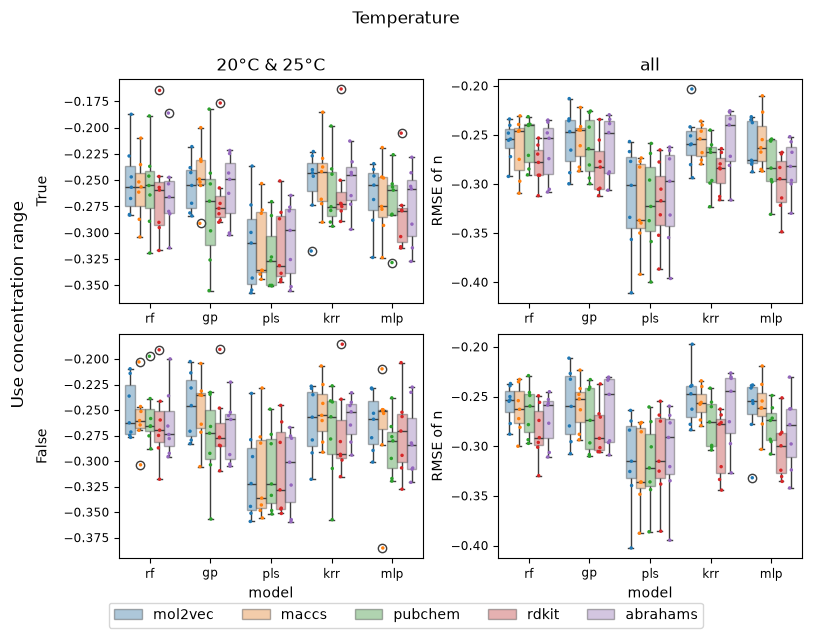

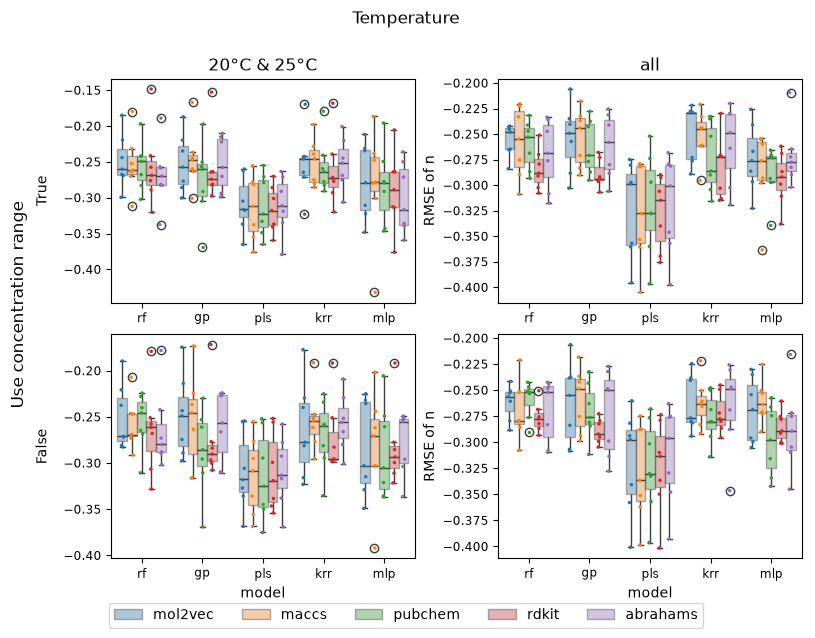

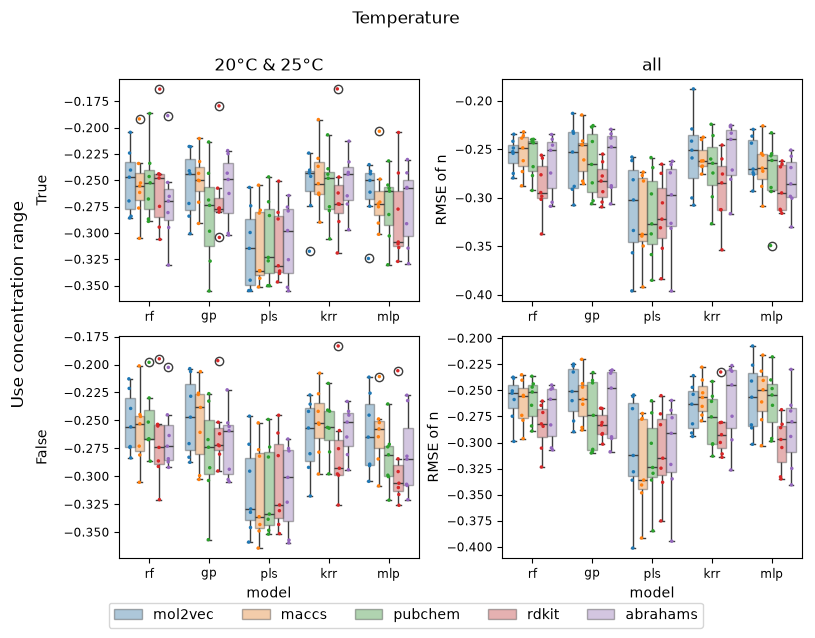

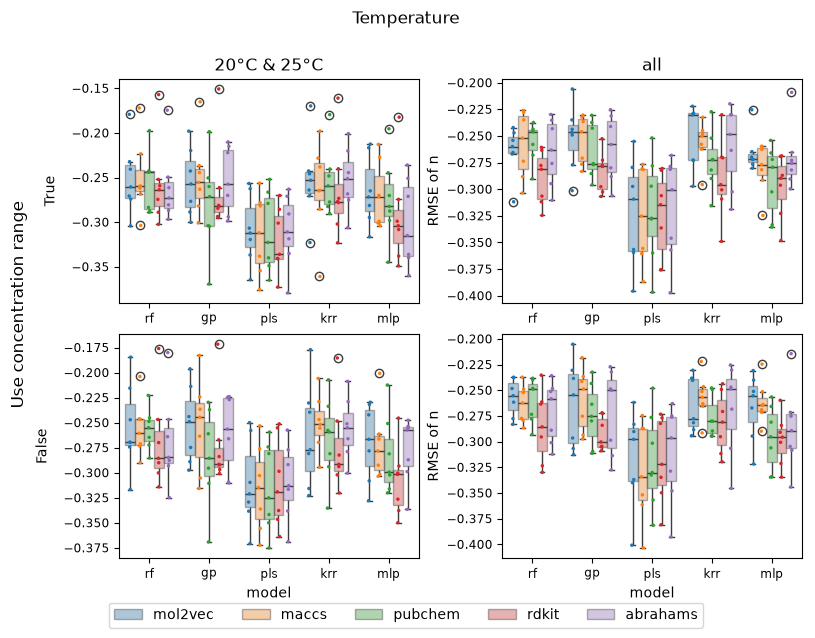

In [4]:
for filter, salinities in (
    ("is_linear_fit", ["seawater", "all_water", "all_vals"]),
    ("is_non_linear_fit", ['freshwater']),
    ("iso_fit_as_bool", ["freshwater", "seawater", "all_water", "all_vals"]),
    ("ooms+fit_as_bool", ["freshwater", "seawater", "all_water", "all_vals"]),
    ("has_enough_ooms", ["freshwater", "seawater", "all_water", "all_vals"]),
):
    MODEL_DIR = Path(os.getcwd()) / "models" / filter

    all_data = load_results(
        dir=MODEL_DIR, flatten=True, r2_cutoff=0.85, target=['kf', 'n']
    )

    kf_data = all_data[all_data['target'] == 'kf']
    n_data = all_data[all_data['target'] == 'n']
    
    plot_path = Path(os.getcwd()) / "plots" / "extra_plots" / filter
    os.makedirs(plot_path, exist_ok=True)

    for param in ('kf', 'n'):
        all_data = kf_data if param == 'kf' else n_data
        targetname = r"$\log(K_f)$" if param == 'kf' else "n"
        for salinity in salinities:
            _plot_bow_facet(all_data[all_data['salinity'] == salinity], sorbent='name', targetname=targetname)
            plt.savefig(plot_path / f"{param}_name_{salinity}_group_embeddings.pdf", dpi=1500, bbox_inches="tight")
            plt.show()
            _plot_bow_facet(all_data[all_data['salinity'] == salinity], sorbent='comp', targetname=targetname)
            plt.savefig(plot_path / f"{param}_composition_{salinity}_group_embeddings.pdf", dpi=1500, bbox_inches="tight")
            plt.show()

    

## RMSE distribution plots similar to S12

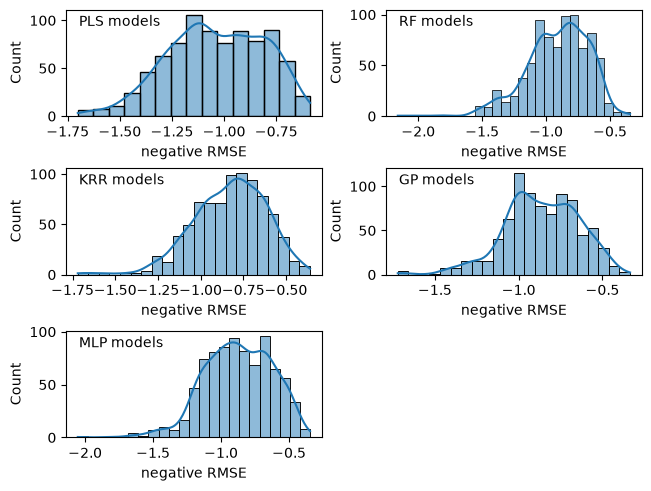

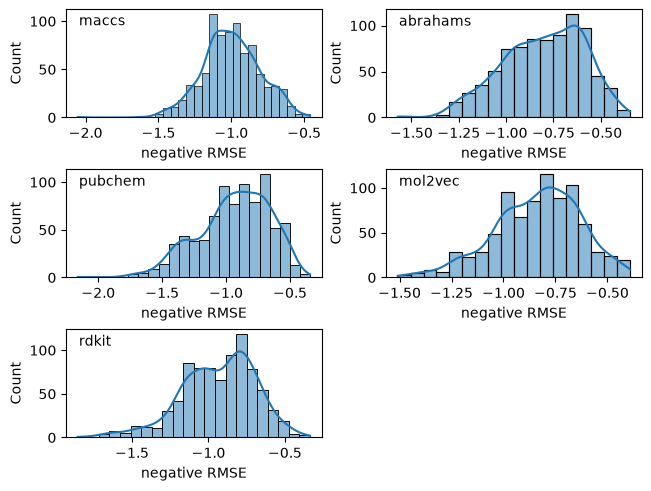

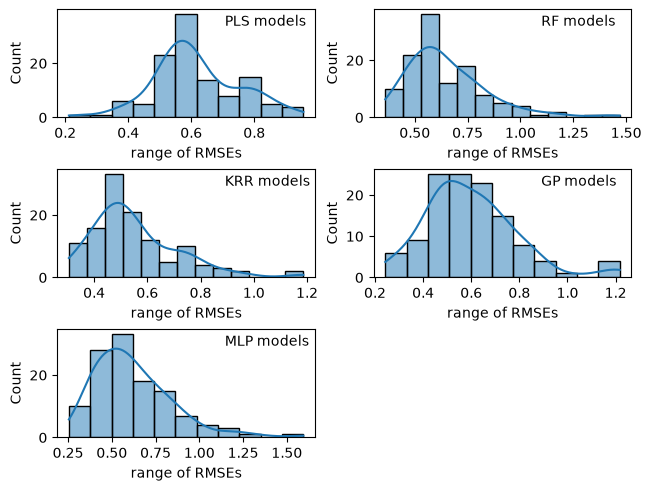

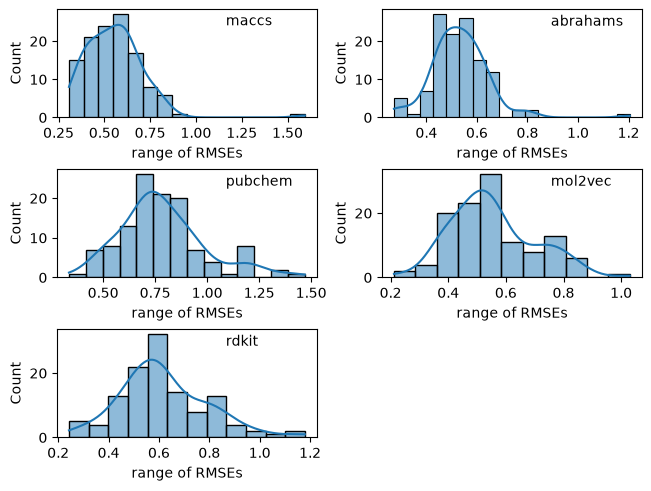

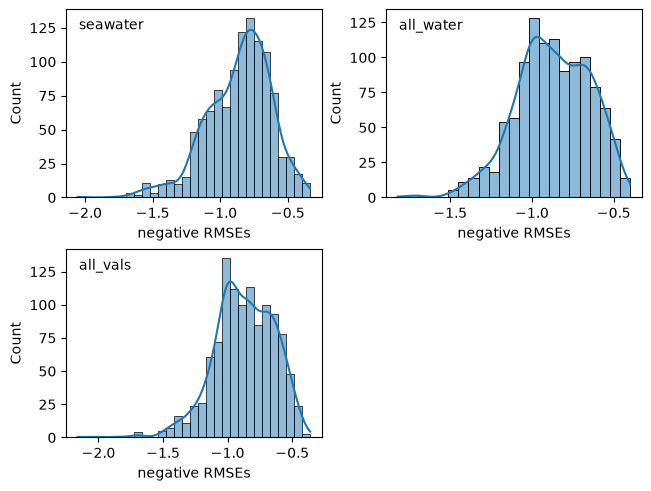

...

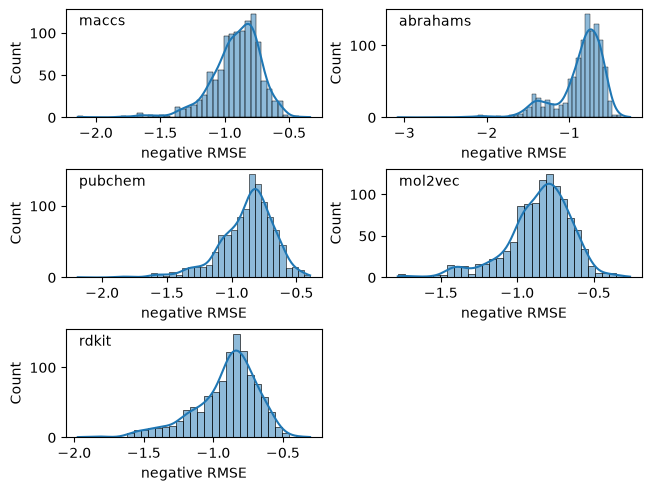

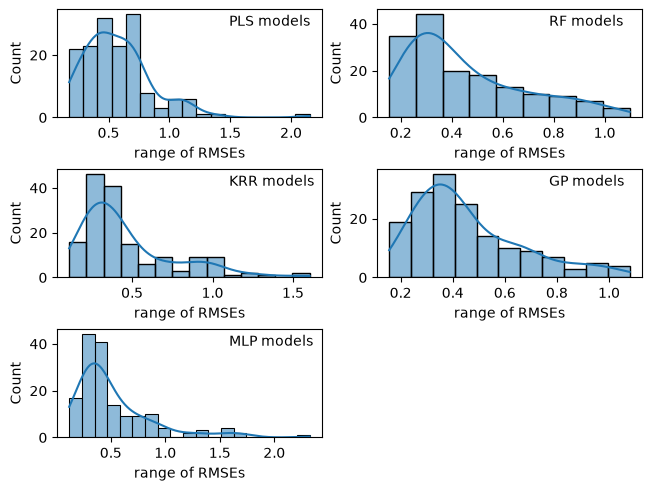

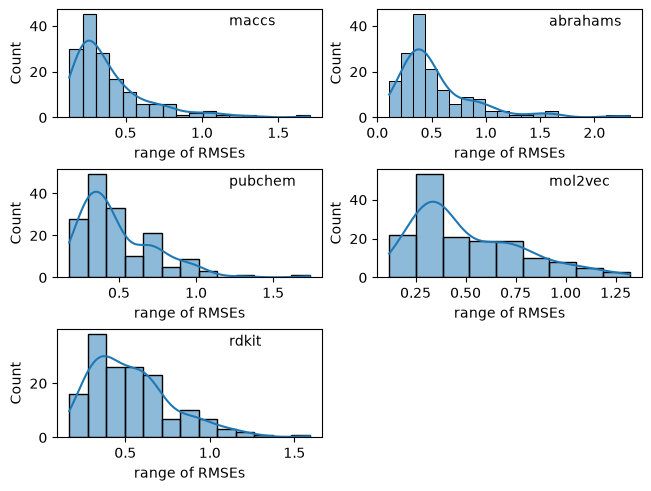

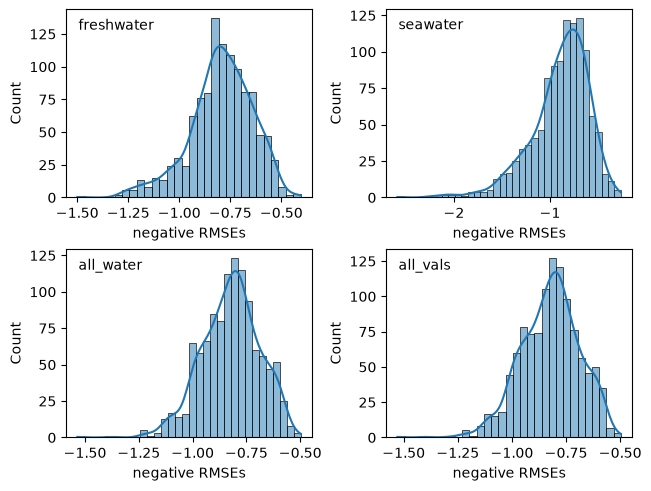

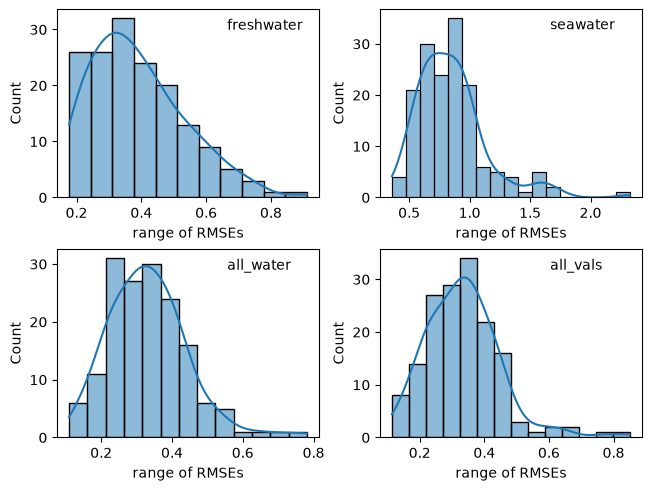

In [5]:
for filter, salinities in (
    ("is_linear_fit", ["seawater", "all_water", "all_vals"]),
    ("is_non_linear_fit", ['freshwater']),
    ("iso_fit_as_bool", ["freshwater", "seawater", "all_water", "all_vals"]),
    ("ooms+fit_as_bool", ["freshwater", "seawater", "all_water", "all_vals"]),
    ("has_enough_ooms", ["freshwater", "seawater", "all_water", "all_vals"]),
):
    MODEL_DIR = Path(os.getcwd()) / "models" / filter

    all_data = load_results(
        dir=MODEL_DIR, flatten=True, r2_cutoff=0.85, target=['kf', 'n']
    )

    kf_data = all_data[all_data['target'] == 'kf']

    plot_path = Path(os.getcwd()) / "plots" / "extra_plots" / filter

    fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
    for ax, model in zip(axs.reshape(-1), ('pls', 'rf', 'krr', 'gp', 'mlp')):
        model_data = kf_data[(kf_data['model'] == model)].explode('score').reset_index(drop=True)
        sns.histplot(
            model_data[model_data['score'] > -100], x = 'score', ax=ax, kde=True
        )
        ax.text(0.05, 0.95, f"{model.upper()} models", transform=ax.transAxes, fontsize=10,
                verticalalignment='top')
        ax.set(xlabel=("negative RMSE"))
    axs.reshape(-1)[-1].remove()
    plt.savefig(plot_path / "rmse-dist-models.pdf", dpi=1500, bbox_inches="tight")
    plt.show()

    fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
    for ax, emb in zip(axs.reshape(-1), ('maccs', 'abrahams', 'pubchem', 'mol2vec', 'rdkit')):
        model_data = kf_data[(kf_data['fingerprint'] == emb)].explode('score').reset_index(drop=True)
        sns.histplot(
            model_data[model_data['score'] > -100], x = 'score', ax=ax, kde=True
        )
        ax.text(0.05, 0.95, f"{emb}", transform=ax.transAxes, fontsize=10,
                verticalalignment='top')
        ax.set(xlabel=("negative RMSE"))
    axs.reshape(-1)[-1].remove()
    plt.savefig(plot_path / "rmse-dist-embeddings.pdf", dpi=1500, bbox_inches="tight")
    plt.show()

    kf_data['range'] = kf_data['score'].apply(lambda x: x.max() - x.min())
    fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
    for ax, model in zip(axs.reshape(-1), ('pls', 'rf', 'krr', 'gp', 'mlp')):
        model_data = kf_data[(kf_data['model'] == model)]
        sns.histplot(
            model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
        )
        ax.text(0.65, 0.95, f"{model.upper()} models", transform=ax.transAxes, fontsize=10,
                verticalalignment='top')
        ax.set(xlabel=("range of RMSEs"))
    axs.reshape(-1)[-1].remove()
    plt.savefig(plot_path / "rmse-range-models.pdf", dpi=1500, bbox_inches="tight")
    plt.show()

    fig, axs = plt.subplots(ncols=2, nrows=3, layout='constrained') #figsize=(9*0.8, 9*0.72))
    for ax, emb in zip(axs.reshape(-1), ('maccs', 'abrahams', 'pubchem', 'mol2vec', 'rdkit')):
        model_data = kf_data[(kf_data['fingerprint'] == emb)]
        sns.histplot(
            model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
        )
        ax.text(0.65, 0.95, f"{emb}", transform=ax.transAxes, fontsize=10,
                verticalalignment='top')
        ax.set(xlabel=("range of RMSEs"))
    axs.reshape(-1)[-1].remove()
    plt.savefig(plot_path / "rmse-range-embeddings.pdf", dpi=1500, bbox_inches="tight")
    plt.show()

    if len(salinities) > 1:
        kf_data['range'] = kf_data['score'].apply(lambda x: x.max() - x.min())
        fig, axs = plt.subplots(ncols=2, nrows=2, layout='constrained') #figsize=(9*0.8, 9*0.72))
        for ax, sal in zip(axs.reshape(-1), salinities):
            model_data = kf_data[(kf_data['salinity'] == sal) & (kf_data['model'] != 'pls')].explode('score').reset_index(drop=True)
            sns.histplot(
                model_data[model_data['score'] > -100], x='score', ax=ax, kde=True
            )
            ax.text(0.05, 0.95, f"{sal}", transform=ax.transAxes, fontsize=10,
                    verticalalignment='top')
            ax.set(xlabel=("negative RMSEs"))
        if len(salinities) < 4:
            assert (len(salinities) == 3)
            axs.reshape(-1)[-1].remove()
        plt.savefig(plot_path / "rmse-dist-salinity.pdf", dpi=1500, bbox_inches="tight")
        plt.show()

        fig, axs = plt.subplots(ncols=2, nrows=2, layout='constrained') #figsize=(9*0.8, 9*0.72))
        for ax, sal in zip(axs.reshape(-1), ('freshwater', 'seawater', 'all_water', 'all_vals')):
            model_data = kf_data[(kf_data['salinity'] == sal) & (kf_data['model'] != 'pls')]
            sns.histplot(
                model_data[model_data['range'] < 100], x = 'range', ax=ax, kde=True
            )
            ax.text(0.65, 0.95, f"{sal}", transform=ax.transAxes, fontsize=10,
                    verticalalignment='top')
            ax.set(xlabel=("range of RMSEs"))
        plt.savefig(plot_path / "rmse-range-salinity.pdf", dpi=1500, bbox_inches="tight")
        plt.show()